# Balanceo y PCA

## Configuración

In [1]:
import warnings, os, json
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (RandomForestClassifier, ExtraTreesClassifier,
                              HistGradientBoostingClassifier)
from sklearn.metrics import (f1_score, accuracy_score, precision_score, recall_score,
                             roc_auc_score, confusion_matrix, precision_recall_curve,
                             roc_curve, auc)
from imblearn.over_sampling import RandomOverSampler, SMOTE, BorderlineSMOTE, ADASYN
from imblearn.combine import SMOTETomek
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostClassifier

SEED = 42
np.random.seed(SEED)
plt.rcParams['figure.dpi'] = 110
sns.set_style('whitegrid')

# ---- Roster de modelos (mismo orden que Sprint 0) ----
MODEL_COLORS = {
    'KNN':                  'blue',
    'Reg. Logística':       'orange',
    'SVM (RBF)':            'teal',
    'MLP':                  'magenta',
    'Árbol de Decisión':    'green',
    'Random Forest':        'red',
    'ExtraTrees':           'olive',
    'HistGradientBoosting': 'brown',
    'XGBoost':              'purple',
    'LightGBM':             'darkcyan',
    'CatBoost':             'goldenrod',
}
MODELOS = list(MODEL_COLORS.keys())

# ---- Datos y split (idénticos al Sprint 0) ----
df = pd.read_csv('../data/processed/data_procesada.csv')
EXCLUIR = ['Au_ppm', 'target_Au', 'East', 'North', 'Level']
FEATURES = [c for c in df.columns if c not in EXCLUIR]
X = df[FEATURES].copy()
y = df['target_Au'].astype(int).copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=SEED)

# ---- Cargar resultado del Sprint 0 ----
with open('outputs_sprint0/resumen_sprint0.json') as f:
    RESUMEN_S0 = json.load(f)
F1_SPRINT0 = RESUMEN_S0['f1_final']

os.makedirs('outputs_sprint1', exist_ok=True)
print(f'Modelos: {len(MODELOS)} | Features: {len(FEATURES)}')
print(f'Train: {X_train.shape} dist={y_train.value_counts().to_dict()}')
print(f'Test : {X_test.shape} dist={y_test.value_counts().to_dict()}')
print(f'F1 ganador Sprint 0: {F1_SPRINT0}')

Modelos: 11 | Features: 46
Train: (1705, 46) dist={0: 1497, 1: 208}
Test : (427, 46) dist={0: 375, 1: 52}
F1 ganador Sprint 0: 0.7629


## Funciones

In [2]:
def crear_modelos():
    """11 modelos con configuración por defecto/ligera (mismo roster que Sprint 0, sin Deep Forest)."""
    return {
        'KNN':                  Pipeline([('sc', StandardScaler()),
                                          ('clf', KNeighborsClassifier(n_neighbors=5))]),
        'Reg. Logística':       Pipeline([('sc', StandardScaler()),
                                          ('clf', LogisticRegression(max_iter=1000, random_state=SEED))]),
        'SVM (RBF)':            Pipeline([('sc', StandardScaler()),
                                          ('clf', SVC(kernel='rbf', random_state=SEED))]),
        'MLP':                  Pipeline([('sc', StandardScaler()),
                                          ('clf', MLPClassifier(hidden_layer_sizes=(100,), max_iter=500,
                                                                random_state=SEED))]),
        'Árbol de Decisión':    Pipeline([('sc', StandardScaler()),
                                          ('clf', DecisionTreeClassifier(random_state=SEED))]),
        'Random Forest':        Pipeline([('sc', StandardScaler()),
                                          ('clf', RandomForestClassifier(n_estimators=100, random_state=SEED,
                                                                         n_jobs=-1))]),
        'ExtraTrees':           Pipeline([('sc', StandardScaler()),
                                          ('clf', ExtraTreesClassifier(n_estimators=100, random_state=SEED,
                                                                       n_jobs=-1))]),
        'HistGradientBoosting': Pipeline([('sc', StandardScaler()),
                                          ('clf', HistGradientBoostingClassifier(random_state=SEED))]),
        'XGBoost':              Pipeline([('sc', StandardScaler()),
                                          ('clf', xgb.XGBClassifier(n_estimators=100, random_state=SEED,
                                                                    eval_metric='logloss',
                                                                    tree_method='hist', n_jobs=-1))]),
        'LightGBM':             Pipeline([('sc', StandardScaler()),
                                          ('clf', lgb.LGBMClassifier(n_estimators=100, random_state=SEED,
                                                                     verbose=-1, n_jobs=-1))]),
        'CatBoost':             Pipeline([('sc', StandardScaler()),
                                          ('clf', CatBoostClassifier(iterations=100, random_seed=SEED,
                                                                     verbose=0, allow_writing_files=False))]),
    }

BALANCEADORES = {
    'Sin balanceo':      None,
    'RandomOverSampler': RandomOverSampler(random_state=SEED),
    'SMOTE':             SMOTE(random_state=SEED, k_neighbors=5),
    'BorderlineSMOTE':   BorderlineSMOTE(random_state=SEED, k_neighbors=5),
    'ADASYN':            ADASYN(random_state=SEED),
    'SMOTETomek':        SMOTETomek(random_state=SEED),
}

def aplicar_balanceo(nombre):
    bal = BALANCEADORES[nombre]
    if bal is None:
        return X_train.copy(), y_train.copy()
    return bal.fit_resample(X_train, y_train)

def scores_pos(modelo, Xte):
    """Probabilidad/score de la clase positiva."""
    clf = modelo.named_steps['clf'] if hasattr(modelo, 'named_steps') else modelo
    if hasattr(clf, 'predict_proba'):
        return modelo.predict_proba(Xte)[:, 1]
    return modelo.decision_function(Xte)

def metricas(yte, y_pred, y_sco):
    return {
        'F1':        f1_score(yte, y_pred),
        'Accuracy':  accuracy_score(yte, y_pred),
        'Precision': precision_score(yte, y_pred, zero_division=0),
        'Recall':    recall_score(yte, y_pred),
        'AUC-ROC':   roc_auc_score(yte, y_sco),
    }

def evaluar_pipeline(modelo, Xtr, ytr, Xte, yte):
    modelo.fit(Xtr, ytr)
    y_pred = modelo.predict(Xte); y_sco = scores_pos(modelo, Xte)
    m = metricas(yte, y_pred, y_sco); m['_pred'] = y_pred; m['_score'] = y_sco
    return m
print('Funciones listas')

Funciones listas


## Balanceo

In [3]:
import time
print('Evaluando 6 métodos de balanceo × 11 modelos ...')
t0_bal = time.time()
f1_bal = pd.DataFrame(index=list(BALANCEADORES), columns=MODELOS, dtype=float)
for nb_bal in BALANCEADORES:
    Xtr_b, ytr_b = aplicar_balanceo(nb_bal)
    for nb_mod, modelo in crear_modelos().items():
        f1_bal.loc[nb_bal, nb_mod] = evaluar_pipeline(modelo, Xtr_b, ytr_b, X_test, y_test)['F1']
    print(f'  {nb_bal} completado')
print(f'Balanceo terminado en {time.time()-t0_bal:.0f}s')

f1_bal = f1_bal.astype(float).round(4)
f1_bal.to_csv('outputs_sprint1/balanceo_f1.csv')

def resaltar_maximo(s):
    estilos = [''] * len(s)
    idx_max = s.idxmax()
    estilos[s.index.get_loc(idx_max)] = 'background-color: coral; color: white; font-weight: bold'
    return estilos

print('\nBalanceo — F1-score (hold-out) por método de balanceo y modelo')
f1_bal.style.apply(resaltar_maximo, axis=0).format('{:.4f}')

Evaluando 6 métodos de balanceo × 11 modelos ...
  Sin balanceo completado
  RandomOverSampler completado
  SMOTE completado
  BorderlineSMOTE completado
  ADASYN completado
  SMOTETomek completado
Balanceo terminado en 63s

Balanceo — F1-score (hold-out) por método de balanceo y modelo


,KNN,Reg. Logística,SVM (RBF),MLP,Árbol de Decisión,Random Forest,ExtraTrees,HistGradientBoosting,XGBoost,LightGBM,CatBoost
Sin balanceo,0.3243,0.6118,0.2333,0.7551,0.6393,0.6437,0.5750,0.7447,0.7629,0.7216,0.7010
RandomOverSampler,0.4895,0.5455,0.4568,0.6602,0.6724,0.6667,0.4722,0.7664,0.7321,0.7736,0.7304
SMOTE,0.5093,0.5860,0.4819,0.7037,0.5481,0.7130,0.6667,0.7521,0.6833,0.7350,0.7241
BorderlineSMOTE,0.5161,0.5526,0.4720,0.7184,0.6269,0.7069,0.6195,0.7627,0.7009,0.7563,0.6942
ADASYN,0.5150,0.5696,0.4790,0.7009,0.5625,0.7027,0.5812,0.7179,0.7059,0.6838,0.7059
SMOTETomek,0.5093,0.5860,0.4848,0.7027,0.5693,0.7069,0.6552,0.7611,0.7179,0.7395,0.7179


## Comparación por método de balanceo

In [4]:
mejor_bal_por_modelo = {mod: f1_bal[mod].idxmax() for mod in MODELOS}
resumen_bal = pd.DataFrame({
    'Mejor método':  [mejor_bal_por_modelo[m] for m in MODELOS],
    'F1 (mejor)':    [round(f1_bal[m].max(),4) for m in MODELOS],
    'F1 (baseline)': [round(f1_bal.loc['Sin balanceo', m],4) for m in MODELOS],
}, index=MODELOS)
resumen_bal['Δ F1'] = (resumen_bal['F1 (mejor)'] - resumen_bal['F1 (baseline)']).round(4)
print('Mejor método de balanceo por modelo:')
resumen_bal

Mejor método de balanceo por modelo:


,Mejor método,F1 (mejor),F1 (baseline),Δ F1
KNN,BorderlineSMOTE,0.5161,0.3243,0.1918
Reg. Logística,Sin balanceo,0.6118,0.6118,0.0000
SVM (RBF),SMOTETomek,0.4848,0.2333,0.2515
MLP,Sin balanceo,0.7551,0.7551,0.0000
Árbol de Decisión,RandomOverSampler,0.6724,0.6393,0.0331
Random Forest,SMOTE,0.7130,0.6437,0.0693
ExtraTrees,SMOTE,0.6667,0.5750,0.0917
HistGradientBoosting,RandomOverSampler,0.7664,0.7447,0.0217
XGBoost,Sin balanceo,0.7629,0.7629,0.0000
LightGBM,RandomOverSampler,0.7736,0.7216,0.0520


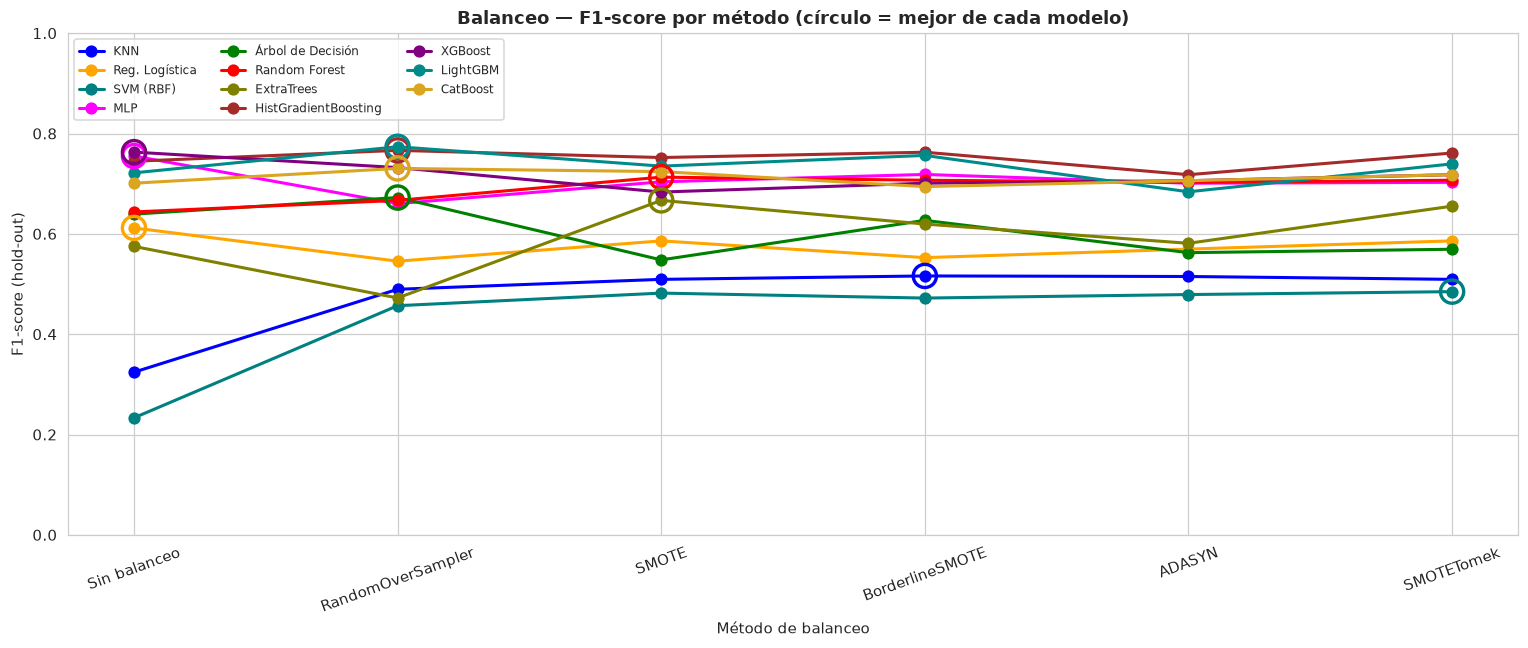

In [5]:
fig, ax = plt.subplots(figsize=(14, 6))
metodos = list(BALANCEADORES); x = np.arange(len(metodos))
for mod in MODELOS:
    ax.plot(x, f1_bal[mod].values, marker='o', lw=2, markersize=7, color=MODEL_COLORS[mod], label=mod)
for mod in MODELOS:
    xi = metodos.index(mejor_bal_por_modelo[mod])
    ax.scatter([xi], [f1_bal.loc[mejor_bal_por_modelo[mod], mod]], s=230, facecolors='none',
               edgecolors=MODEL_COLORS[mod], linewidths=2.2, zorder=5)
ax.set_xticks(x); ax.set_xticklabels(metodos, rotation=20)
ax.set_xlabel('Método de balanceo'); ax.set_ylabel('F1-score (hold-out)'); ax.set_ylim(0, 1)
ax.set_title('Balanceo — F1-score por método (círculo = mejor de cada modelo)', fontweight='bold')
ax.legend(fontsize=8, ncol=3, loc='upper left')
plt.tight_layout(); plt.savefig('outputs_sprint1/balanceo_f1_comparacion.png', bbox_inches='tight'); plt.show()

## Análisis Principal de Componentes (PCA)

### Funciones auxiliares

In [6]:
def sustento_pca(Xtr_scaled):
    """Devuelve var_acum, eigenvalues y umbrales n80/n90/n95/kaiser."""
    pca = PCA(random_state=SEED).fit(Xtr_scaled)
    var_acum = np.cumsum(pca.explained_variance_ratio_)
    eigen = pca.explained_variance_
    n = {u: int(np.argmax(var_acum >= u)+1) for u in (.80,.90,.95)}
    n['kaiser'] = int(np.sum(eigen > 1))
    return var_acum, eigen, n

def graficar_sustento(var_acum, eigen, n, titulo, fname):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    comp = np.arange(1, len(var_acum)+1)
    axes[0].plot(comp, var_acum, marker='o', ms=3, color='blue', lw=1.6)
    for u, c in [(.80,'green'),(.90,'orange'),(.95,'red')]:
        axes[0].axhline(u, ls='--', color=c, alpha=.7); axes[0].axvline(n[u], ls=':', color=c, alpha=.7)
        axes[0].text(n[u]+0.3, u-0.06, f'{int(u*100)}% → {n[u]}', color=c, fontweight='bold', fontsize=9)
    axes[0].set_xlabel('Nº componentes'); axes[0].set_ylabel('Varianza explicada acumulada')
    axes[0].set_title(f'Varianza acumulada — {titulo}', fontweight='bold')
    axes[1].plot(comp, eigen, marker='o', ms=3, color='purple', lw=1.5)
    axes[1].axhline(1.0, ls='--', color='red', label='Kaiser (eigenvalue=1)')
    axes[1].axvline(n['kaiser'], ls=':', color='red', alpha=.7)
    axes[1].text(n['kaiser']+0.3, max(eigen)*0.6, f"Kaiser → {n['kaiser']}", color='red', fontweight='bold', fontsize=9)
    axes[1].set_xlabel('Nº componentes'); axes[1].set_ylabel('Eigenvalue')
    axes[1].set_title(f'Scree plot + Kaiser — {titulo}', fontweight='bold'); axes[1].legend()
    plt.tight_layout(); plt.savefig(fname, bbox_inches='tight'); plt.show()

N_FEATURES = len(FEATURES)

def barrido_pca(Xtr_b, ytr_b):
    """F1 hold-out para n=1..N_FEATURES y cada modelo. Devuelve DataFrame."""
    sc = StandardScaler().fit(Xtr_b)
    Xtr_s = sc.transform(Xtr_b); Xte_s = sc.transform(X_test)
    tab = pd.DataFrame(index=range(1, N_FEATURES+1), columns=MODELOS, dtype=float)
    for n in range(1, N_FEATURES+1):
        pca = PCA(n_components=n, random_state=SEED).fit(Xtr_s)
        Xtr_p = pca.transform(Xtr_s); Xte_p = pca.transform(Xte_s)
        for nb_mod, base in crear_modelos().items():
            clf = base.named_steps['clf']
            clf.fit(Xtr_p, ytr_b)
            tab.loc[n, nb_mod] = f1_score(y_test, clf.predict(Xte_p))
    return tab.astype(float).round(4)

def top5_por_modelo(tab, etiqueta):
    filas = []
    for mod in MODELOS:
        top = tab[mod].sort_values(ascending=False).head(5)
        for rank,(n,f1) in enumerate(top.items(),1):
            filas.append({'Modelo':mod,'Escenario':etiqueta,'Rank':rank,'n_comp':int(n),'F1':f1})
    return pd.DataFrame(filas)

def grafico_barrido(tab, titulo, fname):
    fig, ax = plt.subplots(figsize=(14, 6))
    for mod in MODELOS:
        ax.plot(tab.index, tab[mod], marker='o', ms=3, lw=1.7, color=MODEL_COLORS[mod], label=mod)
        n_best = int(tab[mod].idxmax())
        ax.scatter([n_best],[tab[mod].max()], s=200, facecolors='none',
                   edgecolors=MODEL_COLORS[mod], linewidths=2.2, zorder=5)
    ax.set_xlabel(f'Nº de componentes PCA (1–{N_FEATURES})'); ax.set_ylabel('F1-score (hold-out)')
    ax.set_title(titulo, fontweight='bold'); ax.set_xlim(0, N_FEATURES+1); ax.set_ylim(0,1)
    ax.legend(fontsize=8, ncol=3)
    plt.tight_layout(); plt.savefig(fname, bbox_inches='tight'); plt.show()
print('Funciones de PCA listas.')

Funciones de PCA listas.


### PCA sin balanceo (E1)

PCA (sin balanceo) → Kaiser=13 | 80%=14 | 90%=22 | 95%=28


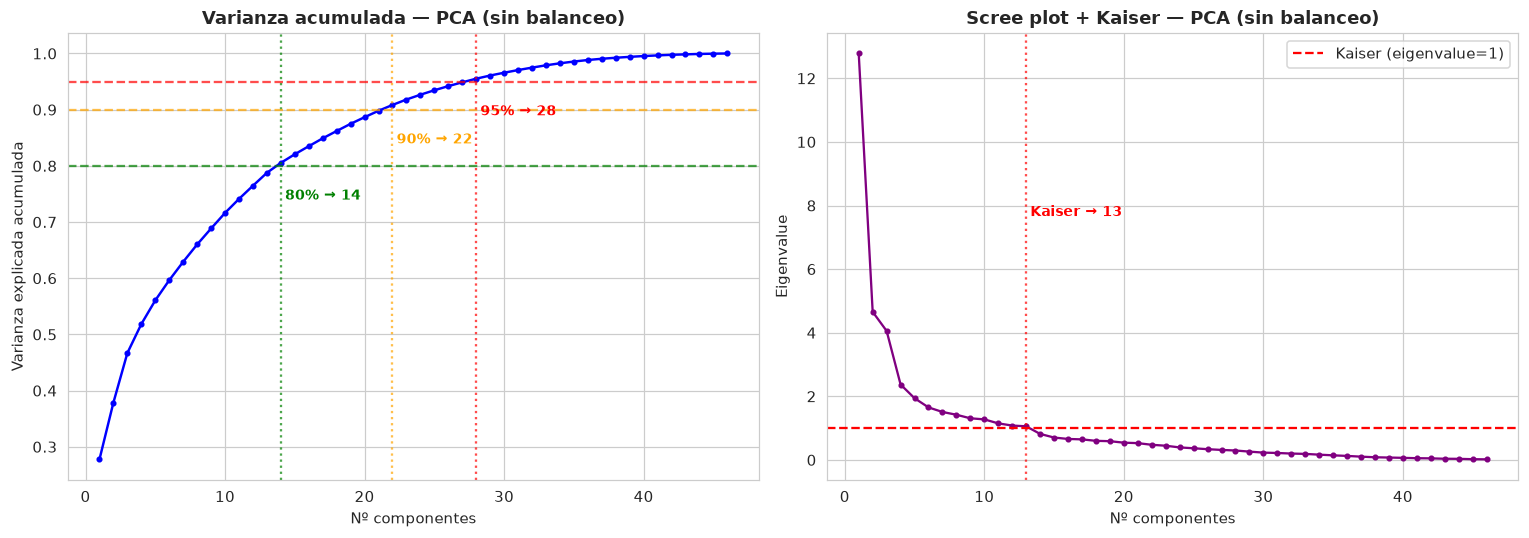

In [7]:
sc0 = StandardScaler().fit(X_train)
va0, eig0, n0 = sustento_pca(sc0.transform(X_train))
print(f"PCA (sin balanceo) → Kaiser={n0['kaiser']} | 80%={n0[.80]} | 90%={n0[.90]} | 95%={n0[.95]}")
graficar_sustento(va0, eig0, n0, 'PCA (sin balanceo)', 'outputs_sprint1/PCA_sinbalanceo.png')

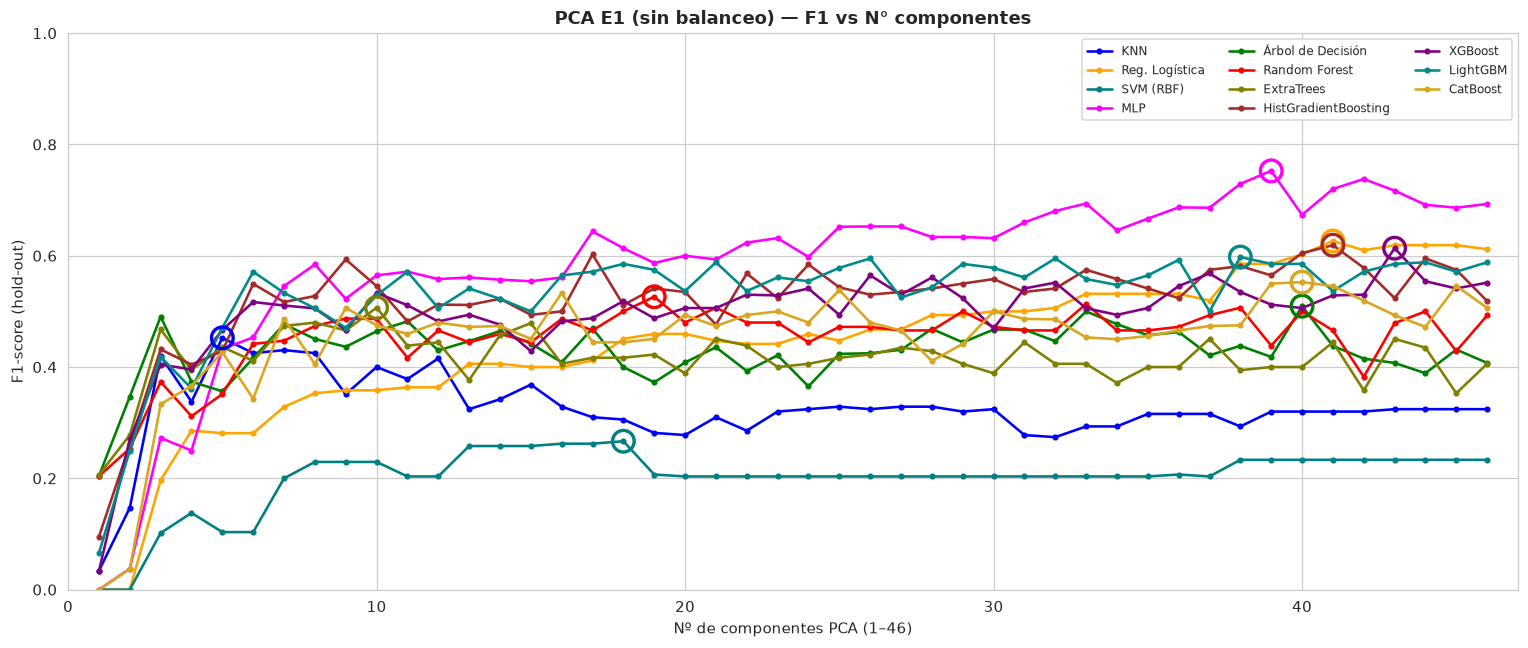

In [8]:
tab_pca_e1 = barrido_pca(X_train, y_train)
tab_pca_e1.to_csv('outputs_sprint1/PCA_sinbalanceo_f1.csv')
grafico_barrido(tab_pca_e1, 'PCA E1 (sin balanceo) — F1 vs N° componentes',
                'outputs_sprint1/PCA_sinbalanceo_comparacion_f1.png')

In [9]:
top5_e1 = top5_por_modelo(tab_pca_e1, 'PCA sin balanceo')
top5_e1.to_csv('outputs_sprint1/PCA_sinbalanceo_top5.csv', index=False)
print('Top-5 (n_comp | F1) por modelo - PCA E1 (sin balanceo):')
top5_e1.assign(comp_F1=lambda d: d['n_comp'].astype(str)+'  ('+d['F1'].map('{:.3f}'.format)+')')\
       .pivot(index='Rank', columns='Modelo', values='comp_F1')

Top-5 (n_comp | F1) por modelo - PCA E1 (sin balanceo):


Modelo,CatBoost,ExtraTrees,HistGradientBoosting,KNN,LightGBM,MLP,Random Forest,Reg. Logística,SVM (RBF),XGBoost,Árbol de Decisión
Rank,,,,,,,,,,,
1,40 (0.553),10 (0.507),41 (0.619),5 (0.452),38 (0.598),39 (0.752),19 (0.526),41 (0.626),18 (0.267),43 (0.614),40 (0.509)
2,39 (0.550),8 (0.480),40 (0.605),7 (0.430),26 (0.595),42 (0.738),33 (0.513),44 (0.619),16 (0.262),37 (0.568),33 (0.500)
3,45 (0.545),15 (0.479),17 (0.602),8 (0.425),32 (0.595),38 (0.729),21 (0.507),45 (0.619),17 (0.262),26 (0.565),3 (0.491)
4,41 (0.545),7 (0.474),44 (0.595),6 (0.425),36 (0.593),41 (0.720),38 (0.507),43 (0.619),15 (0.258),28 (0.561),11 (0.482)
5,25 (0.538),3 (0.468),9 (0.593),3 (0.420),21 (0.588),43 (0.717),44 (0.500),46 (0.612),14 (0.258),44 (0.554),7 (0.477)


### PCA con el mejor balanceo de cada modelo (E2)

Mejor balanceo por modelo: {'KNN': 'BorderlineSMOTE', 'Reg. Logística': 'Sin balanceo', 'SVM (RBF)': 'SMOTETomek', 'MLP': 'Sin balanceo', 'Árbol de Decisión': 'RandomOverSampler', 'Random Forest': 'SMOTE', 'ExtraTrees': 'SMOTE', 'HistGradientBoosting': 'RandomOverSampler', 'XGBoost': 'Sin balanceo', 'LightGBM': 'RandomOverSampler', 'CatBoost': 'RandomOverSampler'}
Métodos únicos a sustentar en PCA (con balanceo): ['BorderlineSMOTE', 'RandomOverSampler', 'SMOTE', 'SMOTETomek', 'Sin balanceo']


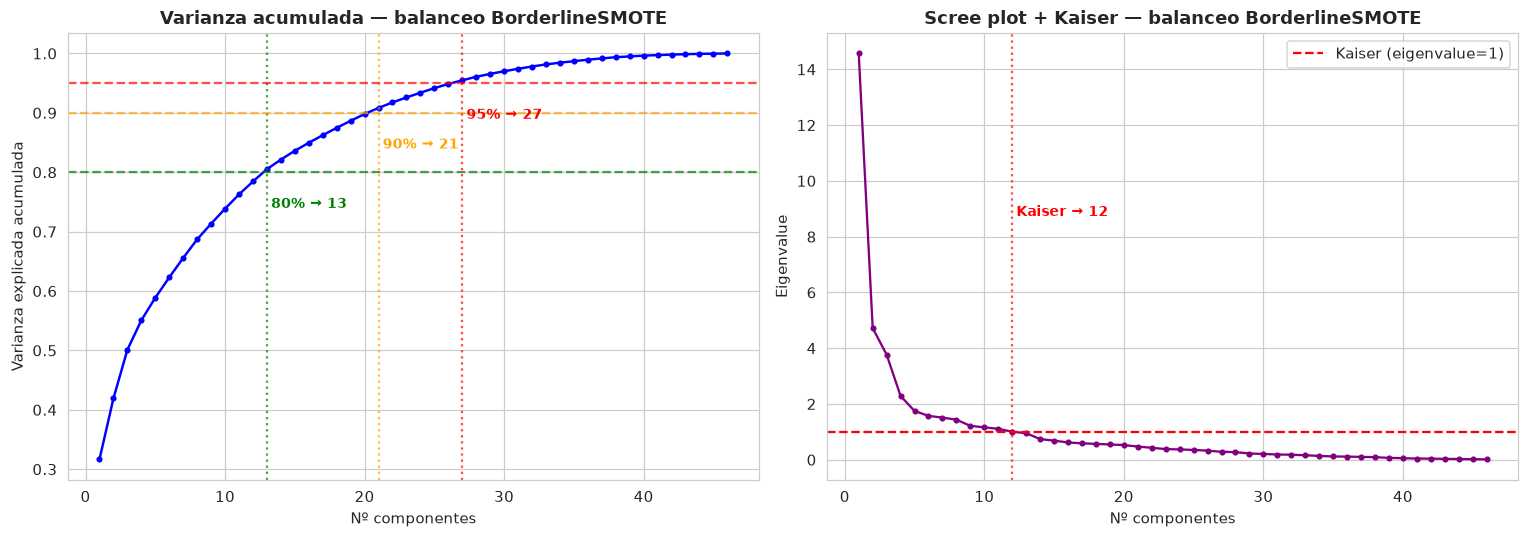

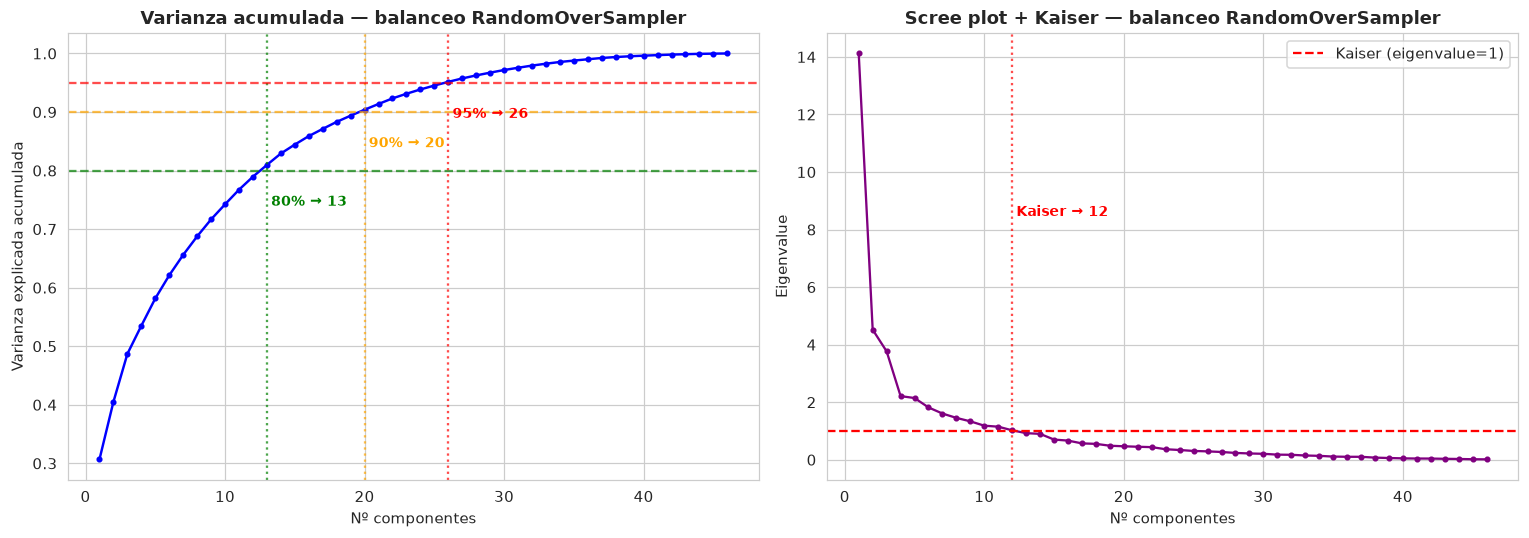

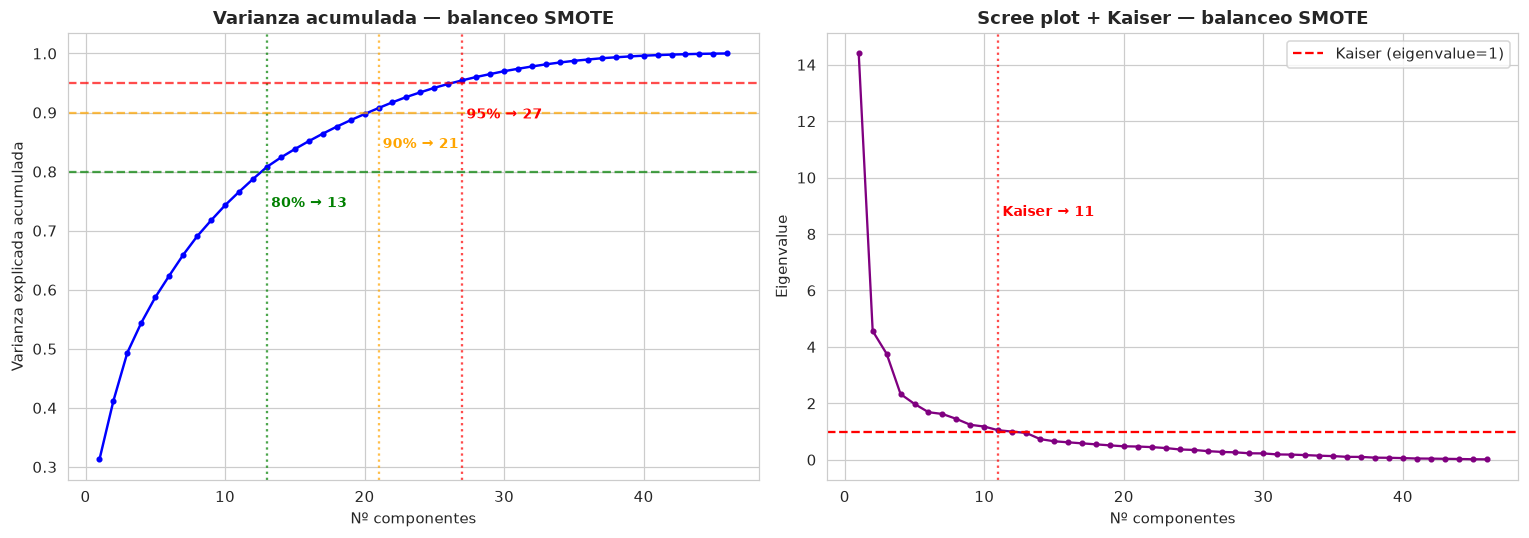

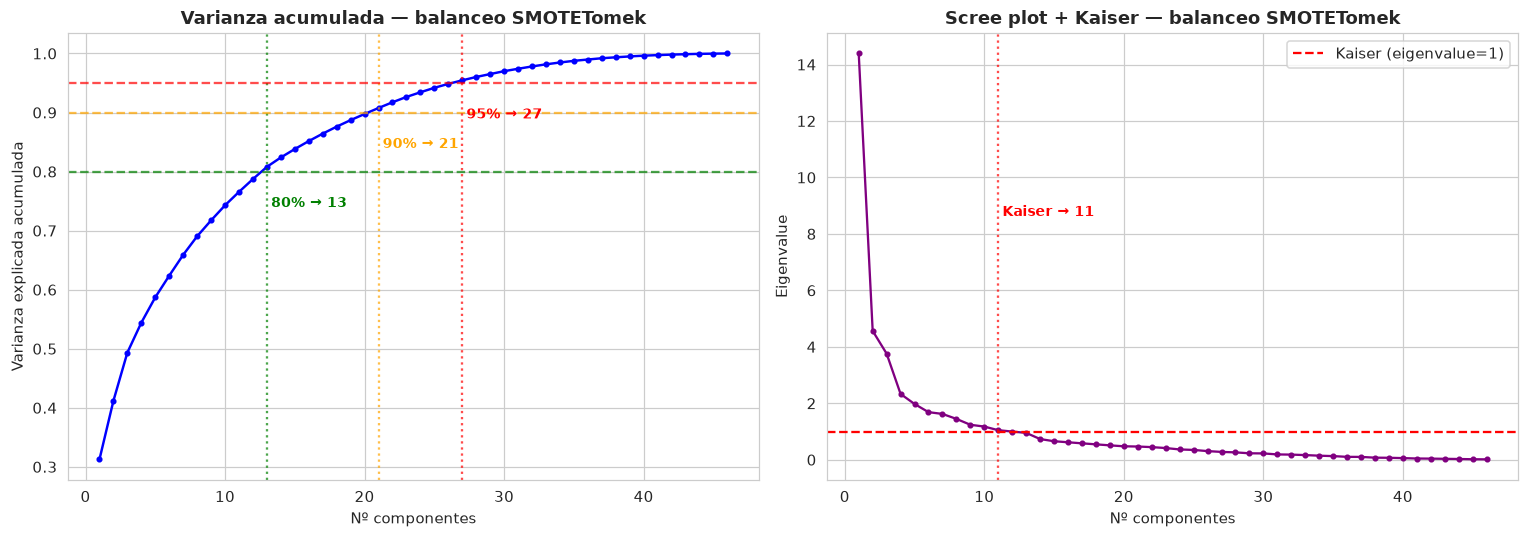

Umbrales de componentes por escenario/balanceo:


,Balanceo,Kaiser,80%,90%,95%
0,Sin balanceo,13,14,22,28
1,BorderlineSMOTE,12,13,21,27
2,RandomOverSampler,12,13,20,26
3,SMOTE,11,13,21,27
4,SMOTETomek,11,13,21,27


In [10]:
# Métodos de balanceo únicos ganadores
metodos_unicos = sorted(set(v for v in mejor_bal_por_modelo.values()))
print('Mejor balanceo por modelo:', mejor_bal_por_modelo)
print('Métodos únicos a sustentar en PCA (con balanceo):', metodos_unicos)

# Sustento + tabla resumen de umbrales por método de balanceo único
filas_umbral = [{'Balanceo':'Sin balanceo','Kaiser':n0['kaiser'],'80%':n0[.80],'90%':n0[.90],'95%':n0[.95]}]
for met in metodos_unicos:
    if met == 'Sin balanceo':
        continue
    Xb, yb = aplicar_balanceo(met)
    va, eig, nn = sustento_pca(StandardScaler().fit(Xb).transform(Xb))
    filas_umbral.append({'Balanceo':met,'Kaiser':nn['kaiser'],'80%':nn[.80],'90%':nn[.90],'95%':nn[.95]})
    graficar_sustento(va, eig, nn, f'balanceo {met}',
                      f'outputs_sprint1/PCA_conbalanceo_{met}.png')
tabla_umbrales = pd.DataFrame(filas_umbral)
tabla_umbrales.to_csv('outputs_sprint1/PCA_conbalanceo_umbrales.csv', index=False)
print('Umbrales de componentes por escenario/balanceo:')
tabla_umbrales

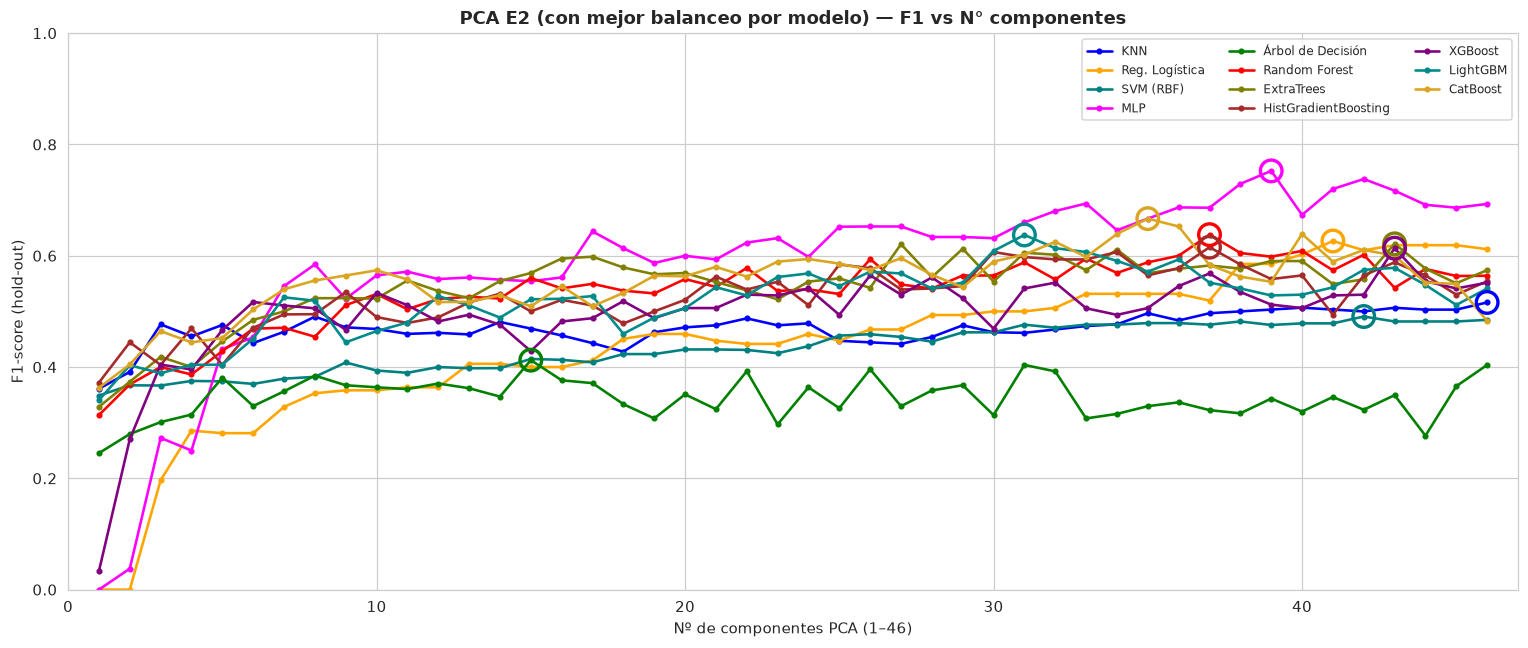

In [11]:
# Barrido PCA E2: cada modelo con SU mejor balanceo (caché por método)
_cache = {}
def barrido_para_metodo(met):
    if met not in _cache:
        Xb, yb = aplicar_balanceo(met)
        _cache[met] = barrido_pca(Xb, yb)
    return _cache[met]

tab_pca_e2 = pd.DataFrame(index=range(1, N_FEATURES+1), columns=MODELOS, dtype=float)
for mod in MODELOS:
    met = mejor_bal_por_modelo[mod]
    tab_pca_e2[mod] = barrido_para_metodo(met)[mod]
tab_pca_e2 = tab_pca_e2.astype(float).round(4)
tab_pca_e2.to_csv('outputs_sprint1/PCA_conbalanceo_f1.csv')
grafico_barrido(tab_pca_e2, 'PCA E2 (con mejor balanceo por modelo) — F1 vs N° componentes',
                'outputs_sprint1/PCA_conbalanceo_comparacion_f1.png')

## Comparativa Final

In [12]:
def eval_config_solo_pca(mod, n, Xtr_b, ytr_b):
    """Evalúa un modelo con PCA de n componentes (sin Pipeline, ya que PCA es externo)."""
    sc = StandardScaler().fit(Xtr_b)
    Xtr_s = sc.transform(Xtr_b); Xte_s = sc.transform(X_test)
    pca = PCA(n_components=n, random_state=SEED).fit(Xtr_s)
    clf = crear_modelos()[mod].named_steps['clf']
    clf.fit(pca.transform(Xtr_s), ytr_b)
    y_pred = clf.predict(pca.transform(Xte_s))
    y_sco = clf.predict_proba(pca.transform(Xte_s))[:,1] if hasattr(clf,'predict_proba') \
            else clf.decision_function(pca.transform(Xte_s))
    return metricas(y_test, y_pred, y_sco)

# Reconstruye las 4 configuraciones (con todas las métricas) para cada modelo
filas_f1 = {}
detalle = {}
for mod in MODELOS:
    # (1) Baseline (sin balanceo, sin PCA)
    m1 = evaluar_pipeline(crear_modelos()[mod], X_train, y_train, X_test, y_test)
    m1 = {k: m1[k] for k in ['F1','Accuracy','Precision','Recall','AUC-ROC']}
    # (2) Solo balanceo (mejor método del modelo)
    met = mejor_bal_por_modelo[mod]
    Xb, yb = aplicar_balanceo(met)
    m2 = evaluar_pipeline(crear_modelos()[mod], Xb, yb, X_test, y_test)
    m2 = {k:m2[k] for k in ['F1','Accuracy','Precision','Recall','AUC-ROC']}
    # (3) Solo PCA (mejor n del E1, sin balanceo)
    n3 = int(tab_pca_e1[mod].idxmax())
    m3 = eval_config_solo_pca(mod, n3, X_train, y_train)
    # (4) Balanceo + PCA (mejor n del E2, con balanceo del modelo)
    n4 = int(tab_pca_e2[mod].idxmax())
    m4 = eval_config_solo_pca(mod, n4, Xb, yb)
    filas_f1[mod] = {'(1) Baseline':m1['F1'], '(2) Balanceo':m2['F1'],
                     '(3) PCA':m3['F1'], '(4) Bal+PCA':m4['F1']}
    detalle[mod] = {'Baseline':m1, 'Balanceo':m2, 'PCA':m3, 'Bal+PCA':m4,
                    '_meta':{'metodo':met,'n_pca_solo':n3,'n_pca_bal':n4}}
print('Configuraciones evaluadas.')
print('Detalle de config por modelo (método balanceo / N° PCA solo / N° PCA con balanceo):')
for mod in MODELOS:
    mt = detalle[mod]['_meta']
    print(f"  {mod}: balanceo={mt['metodo']} | PCA solo={mt['n_pca_solo']}c | Bal+PCA={mt['n_pca_bal']}c")

Configuraciones evaluadas.
Detalle de config por modelo (método balanceo / N° PCA solo / N° PCA con balanceo):
  KNN: balanceo=BorderlineSMOTE | PCA solo=5c | Bal+PCA=46c
  Reg. Logística: balanceo=Sin balanceo | PCA solo=41c | Bal+PCA=41c
  SVM (RBF): balanceo=SMOTETomek | PCA solo=18c | Bal+PCA=42c
  MLP: balanceo=Sin balanceo | PCA solo=39c | Bal+PCA=39c
  Árbol de Decisión: balanceo=RandomOverSampler | PCA solo=40c | Bal+PCA=15c
  Random Forest: balanceo=SMOTE | PCA solo=19c | Bal+PCA=37c
  ExtraTrees: balanceo=SMOTE | PCA solo=10c | Bal+PCA=43c
  HistGradientBoosting: balanceo=RandomOverSampler | PCA solo=41c | Bal+PCA=37c
  XGBoost: balanceo=Sin balanceo | PCA solo=43c | Bal+PCA=43c
  LightGBM: balanceo=RandomOverSampler | PCA solo=38c | Bal+PCA=31c
  CatBoost: balanceo=RandomOverSampler | PCA solo=40c | Bal+PCA=35c


In [13]:
tab_f1_evol = pd.DataFrame(filas_f1).T.round(4)
tab_f1_evol.to_csv('outputs_sprint1/final_evolucion_f1.csv')

def resaltar_maximo_fila(s):
    estilos = [''] * len(s)
    idx_max = s.idxmax()
    estilos[s.index.get_loc(idx_max)] = 'background-color: coral; color: white; font-weight: bold'
    return estilos

print('Evolución de F1 por configuración:')
tab_f1_evol.style.apply(resaltar_maximo_fila, axis=1).format('{:.4f}')

Evolución de F1 por configuración:


,(1) Baseline,(2) Balanceo,(3) PCA,(4) Bal+PCA
KNN,0.3243,0.5161,0.4524,0.5161
Reg. Logística,0.6118,0.6118,0.6265,0.6265
SVM (RBF),0.2333,0.4848,0.2667,0.4908
MLP,0.7551,0.7551,0.7525,0.7525
Árbol de Decisión,0.6393,0.6724,0.5094,0.4124
Random Forest,0.6437,0.7130,0.5263,0.6379
ExtraTrees,0.5750,0.6667,0.5067,0.6214
HistGradientBoosting,0.7447,0.7664,0.6190,0.6154
XGBoost,0.7629,0.7629,0.6136,0.6136
LightGBM,0.7216,0.7736,0.5977,0.6374


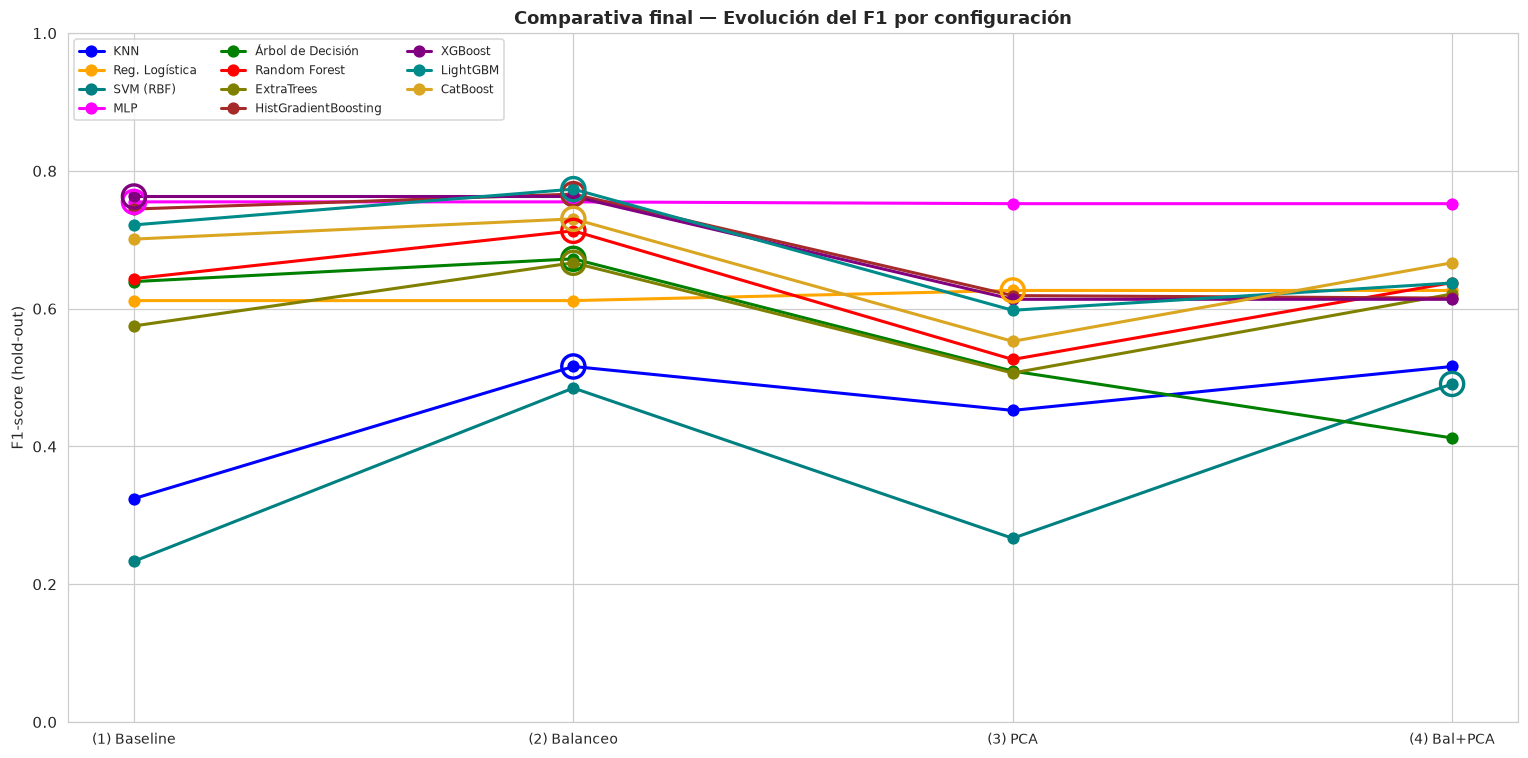

In [14]:
fig, ax = plt.subplots(figsize=(14, 7))
configs = list(next(iter(filas_f1.values())).keys())
x = np.arange(len(configs))
for mod in MODELOS:
    vals = [filas_f1[mod][c] for c in configs]
    ax.plot(x, vals, marker='o', lw=2, markersize=7, color=MODEL_COLORS[mod], label=mod)
    xb = int(np.argmax(vals))
    ax.scatter([xb],[vals[xb]], s=230, facecolors='none', edgecolors=MODEL_COLORS[mod], linewidths=2.2, zorder=5)
ax.set_xticks(x); ax.set_xticklabels(configs, fontsize=9)
ax.set_ylabel('F1-score (hold-out)'); ax.set_ylim(0, 1)
ax.set_title('Comparativa final — Evolución del F1 por configuración', fontweight='bold')
ax.legend(fontsize=8, ncol=3, loc='upper left')
plt.tight_layout(); plt.savefig('outputs_sprint1/final_evolucion_f1.png', bbox_inches='tight'); plt.show()

In [15]:
METRICAS = ['F1','Accuracy','Precision','Recall','AUC-ROC']
filas = []
for mod in MODELOS:
    d = detalle[mod]
    opciones = {'Baseline':d['Baseline'],'Balanceo':d['Balanceo'],'PCA':d['PCA'],'Bal+PCA':d['Bal+PCA']}
    mejor_cfg = max(opciones, key=lambda k: opciones[k]['F1'])
    for met_n in METRICAS:
        antes = d['Baseline'][met_n]; despues = opciones[mejor_cfg][met_n]
        filas.append({'Modelo':mod,'Mejor config':mejor_cfg,'Métrica':met_n,
                      'Antes (baseline)':round(antes,4),'Después':round(despues,4),
                      'Δ':round(despues-antes,4)})
tabla_antes_despues = pd.DataFrame(filas)
tabla_antes_despues.to_csv('outputs_sprint1/final_antes_despues.csv', index=False)
print('Tabla antes/después por modelo (mejor config vs baseline):')
display(tabla_antes_despues.pivot_table(index=['Modelo','Mejor config'], columns='Métrica',
        values=['Antes (baseline)','Después','Δ'], sort=False).round(4))

Tabla antes/después por modelo (mejor config vs baseline):


Antes (baseline)                             \
Métrica                                         F1 Accuracy Precision  Recall   
Modelo               Mejor config                                               
KNN                  Balanceo               0.3243   0.8829    0.5455  0.2308   
Reg. Logística       PCA                    0.6118   0.9227    0.7879  0.5000   
SVM (RBF)            Bal+PCA                0.2333   0.8923    0.8750  0.1346   
MLP                  Baseline               0.7551   0.9438    0.8043  0.7115   
Árbol de Decisión    Balanceo               0.6393   0.8970    0.5571  0.7500   
Random Forest        Balanceo               0.6437   0.9274    0.8000  0.5385   
ExtraTrees           Balanceo               0.5750   0.9204    0.8214  0.4423   
HistGradientBoosting Balanceo               0.7447   0.9438    0.8333  0.6731   
XGBoost              Baseline               0.7629   0.9461    0.8222  0.7115   
LightGBM             Balanceo               0.7216   0.9368    0.7778  0.6731   
CatBoost             Balanceo               0.7010   0.9321    0.7556  0.6538   

                                          Después                             \
Métrica                           AUC-ROC      F1 Accuracy Precision  Recall   
Modelo               Mejor config                                              
KNN                  Balanceo      0.8390  0.5161   0.8244    0.3883  0.7692   
Reg. Logística       PCA           0.9369  0.6265   0.9274    0.8387  0.5000   
SVM (RBF)            Bal+PCA       0.9122  0.4908   0.8056    0.3604  0.7692   
MLP                  Baseline      0.9395  0.7551   0.9438    0.8043  0.7115   
Árbol de Decisión    Balanceo      0.8337  0.6724   0.9110    0.6094  0.7500   
Random Forest        Balanceo      0.9547  0.7130   0.9227    0.6508  0.7885   
ExtraTrees           Balanceo      0.9469  0.6667   0.9063    0.5882  0.7692   
HistGradientBoosting Balanceo      0.9674  0.7664   0.9415    0.7455  0.7885   
XGBoost              Baseline      0.9648  0.7629   0.9461    0.8222  0.7115   
LightGBM             Balanceo      0.9668  0.7736   0.9438    0.7593  0.7885   
CatBoost             Balanceo      0.9567  0.7304   0.9274    0.6667  0.8077   

                                                Δ                             \
Métrica                           AUC-ROC      F1 Accuracy Precision  Recall   
Modelo               Mejor config                                              
KNN                  Balanceo      0.8751  0.1918  -0.0585   -0.1571  0.5385   
Reg. Logística       PCA           0.9344  0.0147   0.0047    0.0508  0.0000   
SVM (RBF)            Bal+PCA       0.8902  0.2575  -0.0867   -0.5146  0.6346   
MLP                  Baseline      0.9395  0.0000   0.0000    0.0000  0.0000   
Árbol de Decisión    Balanceo      0.8417  0.0331   0.0141    0.0522  0.0000   
Random Forest        Balanceo      0.9506  0.0694  -0.0047   -0.1492  0.2500   
ExtraTrees           Balanceo      0.9386  0.0917  -0.0141   -0.2332  0.3269   
HistGradientBoosting Balanceo      0.9705  0.0217  -0.0023   -0.0879  0.1154   
XGBoost              Baseline      0.9648  0.0000   0.0000    0.0000  0.0000   
LightGBM             Balanceo      0.9662  0.0519   0.0070   -0.0185  0.1154   
CatBoost             Balanceo      0.9570  0.0294  -0.0047   -0.0889  0.1538   

                                           
Métrica                           AUC-ROC  
Modelo               Mejor config          
KNN                  Balanceo      0.0361  
Reg. Logística       PCA          -0.0025  
SVM (RBF)            Bal+PCA      -0.0220  
MLP                  Baseline      0.0000  
Árbol de Decisión    Balanceo      0.0080  
Random Forest        Balanceo     -0.0041  
ExtraTrees           Balanceo     -0.0083  
HistGradientBoosting Balanceo      0.0030  
XGBoost              Baseline      0.0000  
LightGBM             Balanceo     -0.0007  
CatBoost             Balanceo      0.0003

## Resumen

In [16]:
# Mejor configuración y F1 final por modelo
mejor_cfg_por_mod = {}
f1_final_por_mod = {}
for mod in MODELOS:
    d = detalle[mod]
    opciones = {'Baseline':d['Baseline'],'Balanceo':d['Balanceo'],'PCA':d['PCA'],'Bal+PCA':d['Bal+PCA']}
    cfg = max(opciones, key=lambda k: opciones[k]['F1'])
    mejor_cfg_por_mod[mod] = cfg
    f1_final_por_mod[mod] = opciones[cfg]['F1']

mejor_modelo = max(f1_final_por_mod, key=f1_final_por_mod.get)
f1_mejor = f1_final_por_mod[mejor_modelo]
cfg_mejor = mejor_cfg_por_mod[mejor_modelo]
met_mejor = detalle[mejor_modelo]['_meta']['metodo']

# Métricas del ganador (acceder al dict correcto según la config)
_cfg_key_map = {'Baseline':'Baseline','Balanceo':'Balanceo','PCA':'PCA','Bal+PCA':'Bal+PCA'}
met_dict_ganador = detalle[mejor_modelo][_cfg_key_map[cfg_mejor]]

resumen1 = {
    'mejor_modelo': mejor_modelo,
    'mejor_config': cfg_mejor,
    'metodo_balanceo': met_mejor,
    'f1_final': round(f1_mejor, 4),
    'f1_sprint0': F1_SPRINT0,
    'mejora_vs_sprint0': round(f1_mejor - F1_SPRINT0, 4),
    'metricas_finales': {m: round(met_dict_ganador[m], 4) for m in METRICAS},
    'f1_por_modelo': {m: round(f1_final_por_mod[m], 4) for m in MODELOS},
    'config_por_modelo': mejor_cfg_por_mod,
    'n_modelos': len(MODELOS),
    'n_features': len(FEATURES),
}
with open('outputs_sprint1/resumen_sprint1.json', 'w') as f:
    json.dump(resumen1, f, indent=2, ensure_ascii=False)

print('════════════ RESUMEN SPRINT 1 ════════════')
print(f'Resultado de balanceo y PCA ({len(MODELOS)} modelos)')
for mod in MODELOS:
    f1_base = RESUMEN_S0['f1_por_modelo'].get(mod, detalle[mod]['Baseline']['F1'])
    f1_new = f1_final_por_mod[mod]
    delta = f1_new - f1_base
    print(f'  {mod}: Sprint0={f1_base:.4f} → {mejor_cfg_por_mod[mod]}='
          f'{f1_new:.4f} (Δ={delta:+.4f})')
print(f'\nMejor modelo')
print(f'  GANADOR: {mejor_modelo} ({cfg_mejor}, {met_mejor}) → F1 = {f1_mejor:.4f}')
print(f'  Evolución del proyecto:')
print(f'    Sprint 0 = {F1_SPRINT0:.4f} (baseline, {RESUMEN_S0["mejor_modelo"]})')
print(f'    Sprint 1 = {f1_mejor:.4f} ({f1_mejor-F1_SPRINT0:+.4f}) — {mejor_modelo} + {mejor_cfg_por_mod[mejor_modelo]}')

print('\nSiguiente paso (Sprint 2): Feature Engineering y clustering.')

════════════ RESUMEN SPRINT 1 ════════════
Resultado de balanceo y PCA (11 modelos)
  KNN: Sprint0=0.3243 → Balanceo=0.5161 (Δ=+0.1918)
  Reg. Logística: Sprint0=0.6118 → PCA=0.6265 (Δ=+0.0147)
  SVM (RBF): Sprint0=0.2333 → Bal+PCA=0.4908 (Δ=+0.2575)
  MLP: Sprint0=0.7551 → Baseline=0.7551 (Δ=+0.0000)
  Árbol de Decisión: Sprint0=0.6393 → Balanceo=0.6724 (Δ=+0.0331)
  Random Forest: Sprint0=0.6437 → Balanceo=0.7130 (Δ=+0.0693)
  ExtraTrees: Sprint0=0.5750 → Balanceo=0.6667 (Δ=+0.0917)
  HistGradientBoosting: Sprint0=0.7447 → Balanceo=0.7664 (Δ=+0.0217)
  XGBoost: Sprint0=0.7629 → Baseline=0.7629 (Δ=-0.0000)
  LightGBM: Sprint0=0.7216 → Balanceo=0.7736 (Δ=+0.0520)
  CatBoost: Sprint0=0.7010 → Balanceo=0.7304 (Δ=+0.0294)

Mejor modelo
  GANADOR: LightGBM (Balanceo, RandomOverSampler) → F1 = 0.7736
  Evolución del proyecto:
    Sprint 0 = 0.7629 (baseline, XGBoost)
    Sprint 1 = 0.7736 (+0.0107) — LightGBM + Balanceo

Siguiente paso (Sprint 2): Feature Engineering y clustering.
